In [24]:
#!/usr/bin/env python
#-*- coding: utf-8 -*-

开始模板匹配...


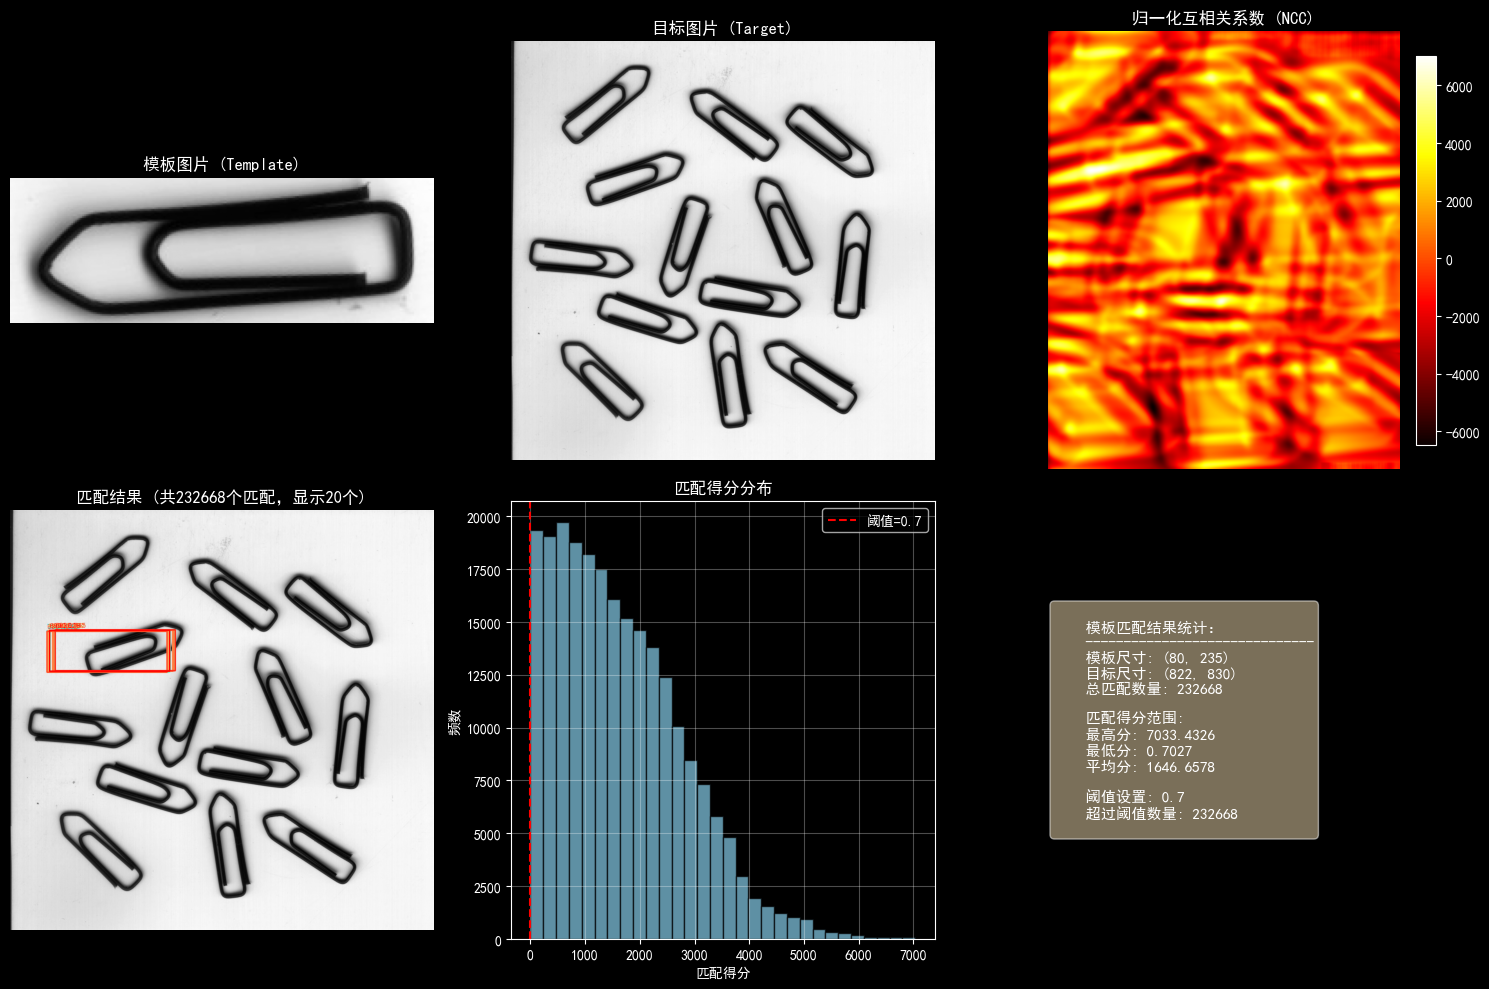

模板匹配结果详情：
找到 232668 个潜在匹配
前10个最高得分的匹配：
  匹配1: 位置(74, 236), 得分: 7033.4326
  匹配2: 位置(75, 236), 得分: 7031.5776
  匹配3: 位置(73, 236), 得分: 7026.0957
  匹配4: 位置(76, 236), 得分: 7023.5620
  匹配5: 位置(77, 236), 得分: 7011.4561
  匹配6: 位置(74, 237), 得分: 7008.4805
  匹配7: 位置(72, 236), 得分: 7007.7476
  匹配8: 位置(73, 237), 得分: 7006.0117
  匹配9: 位置(78, 236), 得分: 7001.4580
  匹配10: 位置(75, 237), 得分: 7000.5264

匹配完成！共找到 232668 个潜在匹配。


In [25]:
# task1_template_matching.ipynb
# 任务1：模板匹配算法（不进行NMS）

# 首先解决matplotlib中文字体和乱码问题
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  # 设置中文字体
matplotlib.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# 设置matplotlib显示中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def load_and_preprocess_images(template_path, target_path):
    """
    加载并预处理图片
    """
    # 读取图片
    template = cv2.imread(template_path, cv2.IMREAD_GRAYSCALE)
    target = cv2.imread(target_path, cv2.IMREAD_GRAYSCALE)

    if template is None:
        raise ValueError(f"无法加载模板图片: {template_path}")
    if target is None:
        raise ValueError(f"无法加载目标图片: {target_path}")

    # 转换为float32以进行归一化
    template = template.astype(np.float32)
    target = target.astype(np.float32)

    # 归一化到0-1范围
    template = (template - np.min(template)) / (np.max(template) - np.min(template) + 1e-8)
    target = (target - np.min(target)) / (np.max(target) - np.min(target) + 1e-8)

    return template, target

def normalized_cross_correlation(image, template):
    """
    计算归一化互相关系数
    """
    # 获取模板尺寸
    t_h, t_w = template.shape
    i_h, i_w = image.shape

    # 初始化结果矩阵
    result = np.zeros((i_h - t_h + 1, i_w - t_w + 1))

    # 计算模板的均值和标准差
    template_mean = np.mean(template)
    template_std = np.std(template)

    # 避免除以零
    if template_std < 1e-8:
        template_std = 1e-8

    # 遍历所有可能的位置
    for y in range(result.shape[0]):
        for x in range(result.shape[1]):
            # 提取当前窗口
            window = image[y:y+t_h, x:x+t_w]

            # 计算窗口的均值和标准差
            window_mean = np.mean(window)
            window_std = np.std(window)

            # 避免除以零
            if window_std < 1e-8:
                window_std = 1e-8

            # 计算归一化互相关系数
            correlation = np.sum((template - template_mean) * (window - window_mean))
            correlation /= (template_std * window_std)

            result[y, x] = correlation

    return result

def template_matching_without_nms(template_path, target_path, threshold=0.7):
    """
    模板匹配算法（不进行NMS）

    参数:
    - template_path: 模板图片路径
    - target_path: 目标图片路径
    - threshold: 匹配阈值，默认0.7

    返回:
    - matches: 所有潜在匹配框 [(x, y, w, h, score), ...]
    - template: 模板图片
    - target: 目标图片
    - ncc_result: NCC匹配结果
    """
    # 加载图片
    template, target = load_and_preprocess_images(template_path, target_path)

    # 计算NCC
    ncc_result = normalized_cross_correlation(target, template)

    # 获取模板尺寸
    t_h, t_w = template.shape

    # 找到所有超过阈值的匹配位置
    matches = []
    height, width = ncc_result.shape

    for y in range(height):
        for x in range(width):
            score = ncc_result[y, x]
            if score >= threshold:
                matches.append({
                    'x': x,
                    'y': y,
                    'width': t_w,
                    'height': t_h,
                    'score': score
                })

    # 按得分排序
    matches.sort(key=lambda m: m['score'], reverse=True)

    return matches, template, target, ncc_result

def visualize_matches(matches, template, target, ncc_result, max_display=20):
    """
    可视化匹配结果

    参数:
    - matches: 匹配结果列表
    - template: 模板图片
    - target: 目标图片
    - ncc_result: NCC结果
    - max_display: 最多显示的匹配框数量
    """
    # 创建可视化
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # 1. 显示模板图片
    axes[0, 0].imshow(template, cmap='gray')
    axes[0, 0].set_title('模板图片 (Template)', fontsize=12)
    axes[0, 0].axis('off')

    # 2. 显示目标图片
    axes[0, 1].imshow(target, cmap='gray')
    axes[0, 1].set_title('目标图片 (Target)', fontsize=12)
    axes[0, 1].axis('off')

    # 3. 显示NCC热力图
    ncc_display = axes[0, 2].imshow(ncc_result, cmap='hot')
    axes[0, 2].set_title('归一化互相关系数 (NCC)', fontsize=12)
    axes[0, 2].axis('off')
    plt.colorbar(ncc_display, ax=axes[0, 2], fraction=0.046, pad=0.04)

    # 4. 显示匹配结果（带匹配框）
    target_rgb = cv2.cvtColor((target * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)

    # 绘制匹配框（限制数量）
    display_matches = matches[:max_display]
    colors = plt.cm.rainbow(np.linspace(0, 1, len(display_matches)))

    for i, match in enumerate(display_matches):
        x, y, w, h = match['x'], match['y'], match['width'], match['height']
        color = colors[i]
        color_rgb = tuple(int(c * 255) for c in color[:3])

        # 绘制矩形框
        cv2.rectangle(target_rgb, (x, y), (x + w, y + h), color_rgb, 2)

        # 在框上方显示得分
        score_text = f"{match['score']:.3f}"
        cv2.putText(target_rgb, score_text, (x, max(y-5, 0)),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, color_rgb, 1)

    axes[1, 0].imshow(target_rgb)
    axes[1, 0].set_title(f'匹配结果 (共{len(matches)}个匹配，显示{len(display_matches)}个)', fontsize=12)
    axes[1, 0].axis('off')

    # 5. 显示得分分布
    scores = [m['score'] for m in matches]
    axes[1, 1].hist(scores, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[1, 1].axvline(x=0.7, color='red', linestyle='--', label='阈值=0.7')
    axes[1, 1].set_xlabel('匹配得分', fontsize=10)
    axes[1, 1].set_ylabel('频数', fontsize=10)
    axes[1, 1].set_title('匹配得分分布', fontsize=12)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # 6. 显示匹配统计信息
    axes[1, 2].axis('off')
    info_text = f"""
    模板匹配结果统计：
    ------------------------------
    模板尺寸: {template.shape}
    目标尺寸: {target.shape}
    总匹配数量: {len(matches)}

    匹配得分范围:
    最高分: {max(scores):.4f}
    最低分: {min(scores):.4f}
    平均分: {np.mean(scores):.4f}

    阈值设置: {0.7}
    超过阈值数量: {len([s for s in scores if s >= 0.7])}
    """
    axes[1, 2].text(0.1, 0.5, info_text, fontsize=11,
                   verticalalignment='center',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

    # 输出详细信息
    print("=" * 60)
    print("模板匹配结果详情：")
    print("=" * 60)
    print(f"找到 {len(matches)} 个潜在匹配")
    print(f"前10个最高得分的匹配：")
    for i, match in enumerate(matches[:10]):
        print(f"  匹配{i+1}: 位置({match['x']}, {match['y']}), 得分: {match['score']:.4f}")
    print("=" * 60)

# 主程序
if __name__ == "__main__":
    # 这里假设您的图片文件名为 template.jpg 和 image.jpg
    # 请根据实际情况修改路径

    # 执行模板匹配
    print("开始模板匹配...")
    matches, template, target, ncc_result = template_matching_without_nms(
        template_path='template.jpg',  # 请修改为实际模板图片路径
        target_path='image.jpg',       # 请修改为实际目标图片路径
        threshold=0.7
    )

    # 可视化结果
    visualize_matches(matches, template, target, ncc_result)

    # 保存匹配结果
    print(f"\n匹配完成！共找到 {len(matches)} 个潜在匹配。")